# CO₂, Arctic Sea Ice, and Industrial Emissions

**Joseph Wong and Jacob Backus**

This notebook checks how climate data are read, compared, and plotted. It follows rising atmospheric CO₂, declining September Arctic sea ice, and the accounting choices behind industry emissions. The final figure places modern CO₂ beside the Vostok ice-core record. That CO₂ comparison gives long-term context; it does not directly reconstruct the temperatures studied by Mann et al. (1998).

## Rules of engagement

- **Plan mode only.** You review and approve the plan before any code runs.
- **Keep your prompts.** Record what you asked for. The prompt is part of your method.
- **Never report a number you have not checked.** Unverified or fabricated data is the one
  automatic-failure condition in this module, and it is no less serious because a model produced
  it.

Setup, GitHub authentication, and model configuration are on the
[course website](https://espm-157.carlboettiger.info/).

### Verification block

Every dataset gets these five questions answered, in your own words, **before** you plot it.
Each part below ends with one.

1. **Extent** — how many rows, what time range, and does that match the source documentation?
2. **Missing data** — how is it encoded, and did your parser catch it?
3. **Units** — what are they, and where in the source is that stated?
4. **Completeness** — the whole dataset, or one piece of it?
5. **Cross-check** — one value confirmed against an independent source.

# Mauna Loa CO₂

The monthly record comes from [NOAA](https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt). We start with the supplied column names, then check them against the source header before using the measurements.

Open this notebook beside the `data` folder in the course's Linux Jupyter environment. Internet access is needed for the large EXIOBASE transaction file, which Ibis reads directly from its public source. Sources are listed in the README. The benchmark table retains actual September 8 measurements; the Ibis query is repeated here.

**Import the analysis tools and standard timing tools.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ibis
import time
import resource

**Read the NOAA text file using the supplied column names.**

In [2]:
names = ["year", "month", "decimal_date", "average", "smooth", "std_days", "uncertainty", "empty"]
raw = pd.read_csv("data/noaa_txt.txt", sep=r"\s+", comment="#", names=names)
raw.head()

,year,month,decimal_date,average,smooth,std_days,uncertainty,empty
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


### Column meanings

NOAA’s header defines the last four columns as deseasonalized CO₂, contributing days, standard deviation of daily means, and uncertainty of the monthly mean.

**Correct the names using NOAA’s header definitions.**

In [3]:
raw.columns = ["year", "month", "decimal_date", "average", "deseasonalized", "ndays", "stdev", "uncertainty"]

**Answer:** The first four names are right. Columns 5–8 should be `deseasonalized`, `ndays`, `stdev`, and `uncertainty`: seasonally adjusted CO₂, contributing days, daily standard deviation, and monthly uncertainty.

The average CO₂ line wouldn't change, but the wrong labels would give incorrect error bars. The column called `empty` actually contains the monthly uncertainty.

### Missing values

Negative codes mark unavailable metadata. We check their counts and effect on summary statistics before replacing them with missing values.

**Count negative sentinel values in the raw file.**

In [4]:
(raw < 0).sum()

year                0
month               0
decimal_date        0
average             0
deseasonalized      0
ndays             195
stdev             196
uncertainty       194
dtype: int64

**Mask the sentinel values and compare the summaries.**

In [5]:
co2 = raw.mask(raw < 0)
pd.DataFrame({"before": raw.mean(), "after": co2.mean(), "minimum": raw.min()})

,before,after,minimum
year,1991.875761,1991.875761,1958.0000
month,6.490865,6.490865,1.0000
decimal_date,1992.374402,1992.374402,1958.2027
average,361.279805,361.279805,312.4200
deseasonalized,361.266090,361.266090,314.4400
ndays,19.165652,25.447284,-1.0000
stdev,-1.997600,0.508816,-9.9900
uncertainty,-0.085286,0.194641,-0.9900


**Inspect the two later rows with flagged standard deviations.**

In [6]:
raw.loc[(raw.stdev < 0) & (raw.year > 1974)]

,year,month,decimal_date,average,deseasonalized,ndays,stdev,uncertainty
213,1975,12,1975.9583,330.77,331.74,-1,-9.99,0.0
313,1984,4,1984.2917,347.37,344.75,2,-9.99,0.0


**Answer:** The missing-value codes are `-1` in `ndays` (195 rows), `-9.99` in `stdev` (196), and `-0.99` in `uncertainty` (194). Neither CO₂ column has negative missing-value codes in this file.

Leaving them in gives a mean standard deviation of −1.9976 ppm instead of 0.5088, and mean uncertainty of −0.0853 ppm instead of 0.1946. The minima become those negative codes, which also give invalid error bars. Mean day count changes from 19.17 to 25.45 after cleaning.

We replaced negative metadata values with missing values and kept the CO₂ measurements and the original raw table. December 1975 and April 1984 also have flagged standard deviations but zero uncertainty; those zeros should not be treated as perfect precision.


### Temporary station change

The source notes say Maunakea supplied observations during the Mauna Loa eruption. The numeric row below shows why that change would be easy to miss without reading the notes.

**Check December 2022, when Maunakea supplied the observations.**

In [7]:
co2.loc[(co2.year == 2022) & (co2.month == 12)]

,year,month,decimal_date,average,deseasonalized,ndays,stdev,uncertainty
777,2022,12,2022.9583,418.99,419.79,24.0,0.57,0.22


**Answer:** The header says Maunakea temporarily replaced Mauna Loa after the November 29, 2022 eruption. The substitution ran from December 2022 through July 4, 2023, with July as a transition month.

December 2022 still looks normal numerically: 418.99 ppm and 24 contributing days. The numbers alone don't reveal the site change, so we marked it on the plot. The header also explains the early Scripps data and interpolation, which matter when interpreting the record.


### Comparing NOAA’s text and CSV files

NOAA also distributes this record as [CSV](https://gml.noaa.gov/ccgg/trends/data.html). Its real column header makes parsing easier, but the missing-value and station notes still matter.

**Read NOAA’s alternative CSV distribution and inspect its header.**

In [8]:
csv = pd.read_csv("data/noaa_csv.csv", comment="#")
csv.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


**Check whether all numeric values agree between the two formats.**

In [9]:
pd.Series({"All TXT and CSV values match": (raw.to_numpy() == csv.to_numpy()).all()})

All TXT and CSV values match    True
dtype: bool

**Answer:** NOAA's [CSV version](https://gml.noaa.gov/ccgg/trends/data.html) has column names, so it avoids guessing positions and parsing uneven spaces. All 821 rows match the TXT values.

It still has comments, missing-value codes, and the same site change. The CSV makes loading easier, but the scientific checks are still needed. Since both files contain the same record, their agreement isn't an independent measurement check.


### Reading the irregular text file with Ibis

A successful read is not enough: the resulting schema must represent the actual columns.

**Inspect the schema produced by Ibis’s default CSV reader.**

In [10]:
con = ibis.duckdb.connect(threads=2, memory_limit="1GB")
con.settings["enable_progress_bar"] = False
trial = con.read_csv("data/noaa_txt.txt")
trial.schema()

ibis.Schema {
  # --------------------------------------------------------------------  string
}

**Answer:** Ibis ran without an error, but it read the whole file as one text column. The TXT has comments and uneven spaces, so it needs the whitespace parsing used above. A tool should fit the file and task; “always use Ibis” isn't a good rule.

### Verification block 1

1. **Extent:** 821 monthly rows, March 1958–July 2026, with no missing months. This matches the saved NOAA file.
2. **Missing data:** Negative codes affect 195 day counts, 196 standard deviations, and 194 uncertainties. We masked those fields and kept the CO₂ values.
3. **Units:** CO₂, standard deviation, and uncertainty are in ppm; `ndays` counts days. [NOAA](https://gml.noaa.gov/ccgg/trends/) defines CO₂ as ppm of dry air.
4. **Completeness:** The full monthly station record in this snapshot, including the early Scripps data and temporary Maunakea measurements.
5. **Cross-check:** May 2025 is 430.51 ppm, which rounds to the 430.5 ppm NOAA value reported by [Scripps](https://scripps.ucsd.edu/news/annual-carbon-dioxide-peak-passes-another-milestone). Scripps' independent measurement is 430.2 ppm, about 0.31 ppm lower. The article does not explain that difference, so this supports the overall concentration without proving agreement at every decimal place.


**Plot monthly and deseasonalized CO₂. The shaded interval marks the temporary observing-site change.**

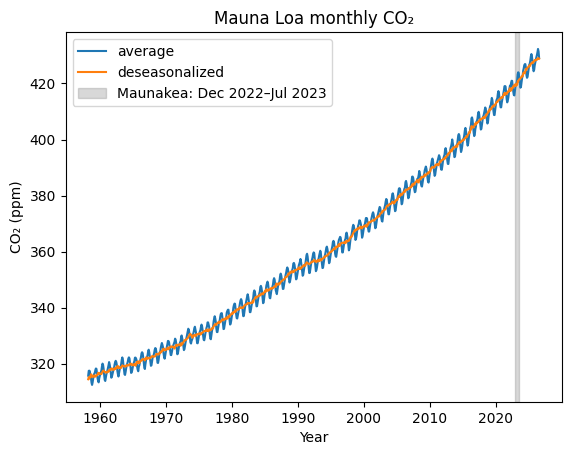

In [11]:
co2.plot(x="decimal_date", y=["average", "deseasonalized"], ylabel="CO₂ (ppm)", title="Mauna Loa monthly CO₂")
plt.axvspan(2022.92, 2023.51, color="gray", alpha=0.3, label="Maunakea: Dec 2022–Jul 2023")
plt.xlabel("Year")
plt.legend()
plt.show()

---

# Arctic Sea Ice

National Snow and Ice Data Center, Sea Ice Index G02135:
[documentation](https://nsidc.org/data/G02135) ·
[data directory](https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/)

### Checking the proposed source

**Recorded task prompt:**

```text
Load Arctic sea ice extent and plot the trend. Give a plan before running code.
```

**Initial plan:** Start with September as a summer ice-loss measure. Try the remembered filename `N_09_extent_v3.0.csv`, but check the directory before downloading. Then check the columns, missing values, dates, and units. Label the graph “September monthly mean Arctic sea ice extent” and load all twelve files for the full monthly record.


**Check the model’s suggested filename against the saved NSIDC directory.**

In [12]:
pd.Series({"Suggested v3 file is listed": "N_09_extent_v3.0.csv" in open("data/seaice_dir.txt").read()})

Suggested v3 file is listed    False
dtype: bool

### Sea-ice file coverage

The directory check distinguishes a remembered filename from one actually present. A September file gives one observation per year, not the complete monthly record.

**Answer:** The suggested `N_09_extent_v3.0.csv` wasn't in the directory. It came from a remembered filename pattern. The directory check caught this before downloading; the available files use `v4.0`.

The corrected September file has 47 rows from 1979–2025, so it only shows September each year. “September monthly mean Arctic sea ice extent” is an accurate title. Calling it the full monthly record would be misleading; that takes all twelve files and gives 574 rows.


### Building the complete monthly sea-ice record

All twelve files are needed. We use September means as the summer comparison and keep every month in the background for context.

**Load all twelve monthly files; NSIDC uses −9999 for missing observations.**

In [13]:
files = [f"data/N_{month:02d}_extent_v4.0.csv" for month in range(1, 13)]
ice = pd.concat([pd.read_csv(f, skipinitialspace=True, na_values=-9999) for f in files], ignore_index=True)

**Order the monthly observations and check missing values.**

In [14]:
ice["date"] = pd.to_datetime(dict(year=ice.year, month=ice.mo, day=1))
ice = ice.sort_values("date")
ice.isna().sum()

year              0
mo                0
source_dataset    2
region            0
extent            2
area              3
date              0
dtype: int64

**Select September monthly means for the summer ice-loss comparison.**

In [15]:
sept = ice.loc[ice.mo == 9]

**Answer:** We loaded all twelve files. The gray line shows every month, and the colored line shows September monthly means. September is the main comparison because it shows how much ice remains near the end of summer. It isn't the daily minimum or the annual mean.

### Verification block 2

1. **Extent:** 574 monthly rows, November 1978–August 2026, including 47 September values from 1979–2025.
2. **Missing data:** `-9999` means missing. Extent is missing in December 1987 and January 1988; area is also missing in August 1987. These stay as gaps.
3. **Units:** Both measures use million km². Extent counts cells with at least 15% ice cover; area accounts for how much ice each cell contains. [NSIDC documentation](https://nsidc.org/data/g02135/versions/4)
4. **Completeness:** All Northern Hemisphere monthly files. The source changes from NSIDC-0051 to NSIDC-0803 in 2025.
5. **Cross-check:** September 2025 is 4.75 million km², matching the [NOAA Arctic Report Card](https://arctic.noaa.gov/report-card/report-card-2025/sea-ice-2025/) with a difference of 0.00 million km². It is 0.15 million km² above the report's daily minimum of 4.60 because a monthly mean averages the whole month instead of selecting the lowest day. This checks the published result and its meaning; both sources use the same underlying observations.


**Plot the complete monthly record and September means. September extent declines over this record.**

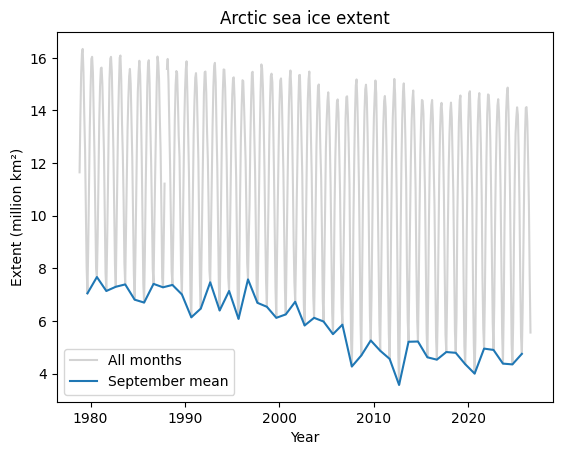

In [16]:
plt.plot(ice.date, ice.extent, color="lightgray", label="All months")
plt.plot(sept.date, sept.extent, label="September mean")
plt.xlabel("Year")
plt.ylabel("Extent (million km²)")
plt.title("Arctic sea ice extent")
plt.legend()
plt.show()

---

# Industrial Output and Memory Use

[EXIOBASE](https://www.exiobase.eu/) provides economic transactions and environmental extensions.
This analysis uses **version 3.8.1**, record 4588235, **2022, industry-by-industry (`ixi`)**,
from [Source Cooperative](https://source.coop/youssef-harby/exiobase-3).

### Initial analysis plan

**Recorded task prompt:**

```text
Compute total industrial output by origin region for 2022 from
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet.
```

**Initial choice:** Use pandas to read the file and sum `value` by `origin_region`. This wasn't a blind test of the model's preferences, since the notebook had already mentioned Ibis.

The supplied URL returned 403. The public S3 endpoint listed on the [source page](https://source.coop/youssef-harby/exiobase-3) worked. Ibis reads `Z` directly from that endpoint; the smaller inputs are saved in `data/`. The earlier local benchmarks used a downloaded copy of the same `Z` file.

One correction matters: summing `Z` gives intermediate sales. Total output also includes final demand, so we calculated `Z + Y` separately.



### Measured memory cost

The original full-pandas benchmark used `pd.read_parquet` on all columns, followed by a regional `groupby`. It was measured in a fresh process. Its result is retained below, so running this notebook does not repeat the large allocation.

**Result:** The original full-pandas run took 20.316 seconds and peaked at 8.287 GiB. It finished in a 14 GiB session, but exceeded the assignment’s roughly 4 GB budget. This is an actual earlier measurement, not an estimate.

### A streaming aggregation

**Recorded constrained prompt:**

```text
Compute the same 2022 Z aggregation by origin_region, using Ibis with its DuckDB
backend. Limit DuckDB's query memory, materialize only the grouped result, and
measure peak memory and wall time in a fresh process.
```

**Local results, September 8, 2026:**

| Approach | Peak memory | Time | Finished? |
|---|---:|---:|---|
| Pandas, all columns | 8.287 GiB | 20.316 s | Yes, with 14 GiB available |
| Ibis / DuckDB, 1 GB engine limit | 0.197 GiB | 0.737 s | Yes |
| Pandas, two columns | 2.000 GiB | 5.355 s | Yes |

Each ran in a fresh process using a local file that could already be cached. These are single runs, so they don't establish a general speed ranking. Timing excludes imports; peak memory includes them. The memory counter reports the process's lifetime peak in KiB, converted here to GiB. DuckDB's limit applies to its engine, not the whole Python process.

The query below reads the public Parquet file, so its elapsed time includes remote access. Its memory value is the current process peak, including earlier cells. The table above keeps the original fresh-process local measurements.

The original remote Ibis run took 76.81 s and peaked at 0.490 GiB. That includes network work, so it is separate from the local comparison.


**Read the full transaction table remotely with Ibis and return only 49 regional totals. The output reports elapsed time and the current process’s lifetime memory peak in Linux units.**

In [17]:
start = time.perf_counter()
z = con.read_parquet(
    "https://s3.us-west-2.amazonaws.com/us-west-2.opendata.source.coop/"
    "youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet"
)
z_total = z.group_by("origin_region").aggregate(total=z.value.sum()).execute()
z_total = z_total.set_index("origin_region").total
pd.Series({"Elapsed seconds": time.perf_counter() - start,
           "Process peak (GiB)": resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024**2})

Elapsed seconds       75.955533
Process peak (GiB)     0.559788
dtype: float64

**Add final demand to intermediate sales. Both use million EUR at current basic prices.**

In [18]:
y = con.read_parquet("data/Y.parquet")
y_total = y.group_by("origin_region").aggregate(total=y.value.sum()).execute()
output = z_total + y_total.set_index("origin_region").total
output.sort_values(ascending=False).rename("Output (million EUR)")

origin_region
CN    4.040769e+07
US    3.602123e+07
JP    9.008407e+06
WA    7.752283e+06
DE    6.804376e+06
IN    6.179297e+06
WM    5.523033e+06
GB    4.678281e+06
FR    4.581877e+06
KR    4.276296e+06
WL    4.176969e+06
IT    3.694195e+06
WF    3.151417e+06
CA    3.038343e+06
BR    3.007281e+06
RU    2.731000e+06
AU    2.495822e+06
ES    2.473095e+06
MX    2.071018e+06
ID    2.068024e+06
NL    1.619630e+06
TR    1.468449e+06
TW    1.367514e+06
CH    1.366515e+06
PL    1.148357e+06
BE    1.033922e+06
IE    9.592310e+05
SE    9.069190e+05
WE    8.505379e+05
AT    8.136413e+05
ZA    6.939663e+05
NO    6.310848e+05
CZ    6.090968e+05
DK    5.926454e+05
FI    4.961384e+05
PT    4.185159e+05
RO    3.985500e+05
GR    3.395630e+05
HU    3.345266e+05
SK    2.313838e+05
LU    2.288318e+05
BG    1.387815e+05
SI    1.053526e+05
HR    9.940129e+04
LT    8.894129e+04
LV    6.541236e+04
EE    6.152680e+04
CY    3.696107e+04
MT    3.170148e+04
Name: Output (million EUR), dtype: float64

**Compare regional output with the original EXIOBASE output file in the same units.**

In [19]:
reference = pd.read_csv("data/x.txt", sep="\t").groupby("region").indout.sum()
((output - reference) / reference).abs().max()

np.float64(7.655226188974745e-13)

**Answer:** In the original benchmark, pandas and Ibis agreed for all 49 regions, with a largest relative difference of about 1.24 × 10⁻¹³. That tiny difference is consistent with floating-point rounding.

Those sums describe intermediate sales. Adding final demand (`Z + Y`) gives total output, which also matches the original `x.txt`. Both are in million EUR at current basic prices. The stored data omit zero entries, explaining why they show 162 sectors while the full index has 163. [EXIOBASE definitions](https://zenodo.org/records/4588235)


### Why tool choice matters

The large Parquet aggregation and the irregular NOAA text file need different approaches. The choice should follow the file, calculation, and available memory.

**Answer:** Pandas is common in tutorials, which may explain the model's first choice. This one example can't tell us what was in its training data.

We'd choose the tool based on the file, calculation, and measured memory use. Pandas worked well for the smaller tables and irregular TXT file; Ibis used much less memory for the large transaction table. Knowing both options helped avoid loading more data than needed.

---

# Industrial CO₂ Emissions

The `F_satellite` table holds the environmental extensions — emissions and resource flows attached
to each industry and region.

```
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet
```

### Environmental stressors and units

Load the table. Before writing any filter, report how many distinct values the `stressor` column
contains, how many of them mention CO2 (with their units and totals), and how many distinct units
appear in the `unit` column across the whole table.

**Read the smaller environmental table and remove whitespace from its labels.**

In [20]:
f = pd.read_parquet("data/F_satellite.parquet")
f["stressor"] = f.stressor.str.strip()
f["unit"] = f.unit.str.strip()

**Survey the stressors and units before choosing an emissions total.**

In [21]:
flows = f.loc[f.stressor.str.contains("CO2")]
pd.Series({"Rows": len(f), "Stressors": f.stressor.nunique(),
           "CO₂ stressors": flows.stressor.nunique(), "Units": f.unit.nunique()})

Rows             1231258
Stressors           1025
CO₂ stressors          6
Units                  8
dtype: int64

**Inspect the six CO₂ flows separately, retaining their units.**

In [22]:
flows.groupby(["stressor", "unit"]).value.sum()

stressor                                        unit
CO2 - agriculture - peat decay - air            kg      1.750859e+11
CO2 - combustion - air                          kg      3.132747e+13
CO2 - non combustion - Cement production - air  kg      1.662875e+12
CO2 - non combustion - Lime production - air    kg      2.536391e+11
CO2 - waste - biogenic - air                    kg      2.098035e+10
CO2 - waste - fossil - air                      kg      6.631248e+08
Name: value, dtype: float64

**Answer:** There are 1,025 stressors, six mentioning CO₂, and eight units. The table above shows the six CO₂ totals, all in kg. The file has 1,231,258 rows.

The original catalogue has 1,113 stressors and nine units. The earlier source check showed that the cloud copy omits zero entries, including 88 entirely zero stressors.

### Checking units before aggregation

The rubric requires compatible units. We inspect the unit breakdown instead of calculating the all-stressor sum suggested in the starter exercise.

**Inspect unit frequencies without adding values from incompatible units.**

In [23]:
f.unit.value_counts().rename("Rows")

unit
kg        653904
kt        198197
Mm3       187647
1000 p     47246
M.hr       47163
M.EUR      45877
TJ         36383
km2        14841
Name: Rows, dtype: int64

**Answer:** An all-stressor total would mix eight units: kg, kt, Mm³, thousand people, million hours, million EUR, TJ, and km². It would have no meaningful unit.

The most common units are kg (653,904 rows) and kt (198,197 rows), a row-count ratio of about 3.30:1. Their physical conversion is 1 kt = 1,000,000 kg. Even after converting mass units, different pollutants and resource flows cannot all be called CO₂ emissions.

### Choosing CO₂ stressors

Compute total CO2 emissions by region for 2022.

You must decide which stressors belong in that total. This is a scientific judgment, not a
string-matching exercise: filtering too narrowly omits real emissions, and matching every name
containing `"CO2"` includes flows that standard greenhouse-gas accounting deliberately excludes.
Find out which, and on what grounds.

Ask your model which to include, then check its reasoning against the accounting convention.

**Which stressors did you include, and why? Which did you exclude, and why?**
**Recorded task prompt:** “Which EXIOBASE CO2 stressors should be included in a 2022 non-biogenic direct industry CO2 total, and why? Check the accounting convention.”


**Inspect peat decay by region before choosing the headline total. Values are in Mt CO₂.**

In [24]:
f.loc[f.stressor.eq("CO2 - agriculture - peat decay - air")].groupby("region").value.sum().div(1e9).sort_values(ascending=False).head()

region
CN    59.573649
IN    37.298095
BR    15.957185
US    11.042567
WM     9.988926
Name: value, dtype: float64

**Select four fossil and process CO₂ flows. Exclude peat decay to match OWID’s land-use boundary, and report biogenic waste separately.**

In [25]:
co2_names = [
    "CO2 - combustion - air",
    "CO2 - non combustion - Cement production - air",
    "CO2 - non combustion - Lime production - air",
    "CO2 - waste - fossil - air",
]

**Sum only the selected kilogram CO₂ flows and convert to million tonnes.**

In [26]:
selected = f.loc[f.stressor.isin(co2_names) & (f.unit == "kg")]
regional = selected.groupby("region").value.sum() / 1e9
regional.sort_values(ascending=False).rename("Industry CO₂, excluding peat decay (Mt)")

region
CN    11257.073112
US     3805.352962
IN     2681.808636
WM     2124.382443
WA     2079.519609
RU     1636.840306
JP     1051.882381
KR      637.972532
WL      605.027971
DE      588.241248
ID      580.633276
WF      535.454735
CA      481.529547
MX      450.237394
TR      444.211091
AU      403.615698
ZA      395.068275
BR      394.537745
WE      354.922664
GB      299.323738
TW      287.966629
PL      250.152152
IT      247.153160
FR      240.246684
ES      200.035168
EE      196.733214
GR      136.914275
NL      135.040717
CZ       97.243649
BE       76.075191
NO       56.437870
RO       56.160438
IE       50.366684
AT       49.160669
FI       41.290979
PT       39.981610
HU       38.750444
DK       38.450806
BG       37.493860
SE       33.087262
CH       31.173119
SK       30.565716
HR       14.895572
CY       12.512886
SI       11.221021
LT        9.834276
LU        9.153582
LV        7.739250
MT        1.174198
Name: Industry CO₂, excluding peat decay (Mt), dtype: float64

**Answer:** We used four fossil and process stressors for the headline industry total:

| Stressor | Choice | Why |
|---|---|---|
| Combustion | Include | CO₂ from fuel use |
| Cement production | Include | CO₂ released during production |
| Lime production | Include | Another source of process CO₂ |
| Agriculture: peat decay | Exclude | Land-use emissions under IPCC; OWID's `co2` excludes land-use change, so including decay breaks that boundary match |
| Waste: fossil | Include | Fossil carbon released from waste |
| Waste: biogenic | Exclude | Reported separately to avoid double counting biomass carbon |

Peat decay belongs to land-use accounting; burning peat as fuel stays in combustion. [IPCC organic-soil guidance](https://www.ipcc-nggip.iges.or.jp/public/wetlands/pdf/Wetlands_separate_files/WS_Chp2_Drained_Inland_Organic_Soils.pdf), [OWID definition](https://ourworldindata.org/grapher/annual-co2-emissions-per-country)

Biogenic CO₂ is reported separately under the [IPCC waste guidance](https://www.ipcc-nggip.iges.or.jp/public/2006gl/pdf/5_Volume5/V5_5_Ch5_IOB.pdf). That does not mean it has no climate effect. This is still a direct industry total, so final-use emissions and the residence-versus-territory difference need separate checks.

### Comparing UK emissions with Our World in Data

[OWID](https://github.com/owid/co2-data) provides an independent national comparison. We match the country and year, check the gap, and compare what each total includes.

**Compare the UK’s 2022 totals. The relative gap uses OWID as the denominator.**

In [27]:
owid = pd.read_csv("data/owid.csv")
uk = owid.query("iso_code == 'GBR' and year == 2022").iloc[0]
gap = regional["GB"] - uk.co2
pd.Series({"OWID (Mt)": uk.co2, "EXIOBASE (Mt)": regional["GB"],
           "Absolute gap (Mt)": abs(gap), "Relative gap (%)": gap / uk.co2 * 100})

OWID (Mt)            311.118000
EXIOBASE (Mt)        299.323738
Absolute gap (Mt)     11.794262
Relative gap (%)      -3.790929
dtype: float64

**Read direct final-use CO₂ from the original file, including households, nonprofit institutions, and government. Its selected flows use kilograms, like the industry flows.**

In [28]:
hh = pd.read_csv("data/F_hh.txt", sep="\t", header=[0, 1], skiprows=[2], index_col=0)
hh.index = hh.index.str.strip()
final_use = hh.loc[co2_names, "GB"].to_numpy().sum() / 1e9
final_use

np.float64(112.482708118)

**Add direct final-use emissions to the industry total, which already excludes peat decay.**

In [29]:
combined = regional["GB"] + final_use
pd.Series({"Industry without peat (Mt)": regional["GB"],
           "Industry plus final use, without peat (Mt)": combined,
           "Gap from OWID (Mt)": combined - uk.co2,
           "Gap from OWID (%)": (combined / uk.co2 - 1) * 100})

Industry without peat (Mt)                    299.323738
Industry plus final use, without peat (Mt)    411.806446
Gap from OWID (Mt)                            100.688446
Gap from OWID (%)                              32.363427
dtype: float64

**Check the direction of the UK’s embodied-emissions trade balance.**

In [30]:
pd.Series({"Territorial CO₂ (Mt)": uk.co2, "Consumption CO₂ (Mt)": uk.consumption_co2,
           "Net embodied imports (Mt)": uk.consumption_co2 - uk.co2})

Territorial CO₂ (Mt)         311.118
Consumption CO₂ (Mt)         502.770
Net embodied imports (Mt)    191.652
dtype: float64

**Answer:** We compared the UK in 2022, matching EXIOBASE `GB` with OWID `GBR`.

| CO₂ measure | Mt | Gap from OWID |
|---|---:|---:|
| OWID national total | 311.118 | Baseline |
| EXIOBASE selected industries, without peat | 299.324 | -3.79% |
| EXIOBASE industries + final use, without peat | 411.806 | +32.36% |

Excluding 0.917 Mt of peat decay lowers the headline industry total to 299.324 Mt, 11.794 Mt below OWID. Industry `F` leaves out 112.483 Mt of direct final-use emissions. Adding those gives 411.806 Mt, or 100.688 Mt above OWID. The combined result stays the same because it already excluded peat.

Two source differences matter. EXIOBASE uses the **residence principle**, including resident operators' activities abroad, such as international transport. OWID uses **territorial emissions** and leaves international aviation and shipping out of national totals. [EXIOBASE methods](https://onlinelibrary.wiley.com/doi/10.1111/jiec.12715), [OWID definition](https://ourworldindata.org/grapher/annual-co2-emissions-per-country)

Also, EXIOBASE 3.8.1 was released in March 2021. Its 2022 values are projections using older emissions data and economic estimates, so they cannot reflect all later events. [Release notes](https://zenodo.org/records/4588235)

These differences explain why exact agreement is not expected. They do not establish how much of the remaining 100.688 Mt comes from each cause, so that remains a limitation.

OWID's consumption total is 502.770 Mt, or 191.652 Mt above its territorial total. This supports the UK being a net importer of embodied CO₂. The industry `F` sum alone cannot test that.

**Match the 44 named countries with OWID in 2022 and show the six largest industry-to-national ratios. Both totals use Mt CO₂.**

In [31]:
iso3 = {"AT":"AUT","AU":"AUS","BE":"BEL","BG":"BGR","BR":"BRA","CA":"CAN","CH":"CHE","CN":"CHN",
        "CY":"CYP","CZ":"CZE","DE":"DEU","DK":"DNK","EE":"EST","ES":"ESP","FI":"FIN","FR":"FRA",
        "GB":"GBR","GR":"GRC","HR":"HRV","HU":"HUN","ID":"IDN","IE":"IRL","IN":"IND","IT":"ITA",
        "JP":"JPN","KR":"KOR","LT":"LTU","LU":"LUX","LV":"LVA","MT":"MLT","MX":"MEX","NL":"NLD",
        "NO":"NOR","PL":"POL","PT":"PRT","RO":"ROU","RU":"RUS","SE":"SWE","SI":"SVN","SK":"SVK",
        "TR":"TUR","TW":"TWN","US":"USA","ZA":"ZAF"}
ow = owid.query("year == 2022").set_index("iso_code").co2
check = pd.DataFrame({"exiobase": regional, "owid": [ow.get(iso3.get(r)) for r in regional.index]}).dropna()
check["ratio"] = check.exiobase / check.owid
check.sort_values("ratio").tail(6).round(2)

,exiobase,owid,ratio
region,,,
DK,38.45,29.09,1.32
IE,50.37,36.68,1.37
NO,56.44,40.83,1.38
CY,12.51,7.07,1.77
GR,136.91,57.61,2.38
EE,196.73,11.97,16.44


**Report the matched-country count, median ratio, and Estonia ratio.**

In [32]:
pd.Series({"Matched countries": len(check), "Median ratio": check.ratio.median(),
           "Estonia ratio": check.loc["EE", "ratio"]})

Matched countries    44.000000
Median ratio          0.954215
Estonia ratio        16.441017
dtype: float64

**Check which sectors account for Estonia’s unusually large total. Values are in Mt CO₂.**

In [33]:
selected.query("region == 'EE'").groupby("sector").value.sum().div(1e9).nlargest(5)

sector
Mining of other non-ferrous metal ores and concentrates    86.931838
Mining of precious metal ores and concentrates             38.415090
Mining of iron ores                                        33.255141
Mining of nickel ores and concentrates                     16.009591
Production of electricity by coal                           7.105700
Name: value, dtype: float64

**Answer:** Across 44 countries, the median ratio is 0.954, down from 0.963 with peat. The totals are broadly similar in scale, but that does not prove they measure the same thing.

Estonia falls only from 196.792 to 196.733 Mt, leaving a ratio of 16.44. Its peat contribution was only 0.058 Mt. The sector check points to mining, so neither peat nor shipping explains this outlier. The cause of that unusually large source estimate is still unresolved.

Residence accounting could contribute to some other high ratios, but this country table alone cannot assign their gaps to shipping or aviation. We should not turn a possible explanation into a measured reconciliation.

### Verification block 3

1. **Extent:** The 2022 files have 37,911,237 `Z` rows, 1,184,764 `Y` rows, and 1,231,258 `F` rows across 49 regions.
2. **Missing data:** `F` has no null values. The original archive check confirmed that absent rows represent zeros; negative values are not automatically missing. In OWID, the selected UK (`GBR`), 2022 row has both CO₂ values present. Other unused fields can be missing.
3. **Units:** Economic flows are in million EUR. The six CO₂ stressors use kg; divide by one billion for Mt. The headline total uses four flows and excludes peat decay and biogenic waste.
4. **Completeness:** These are the 2022 industry tables. `Z` needs `Y` for total output, and industry `F` leaves out direct final-use emissions. The OWID check matches all 44 named countries; the five rest-of-world groups have no matching country row.
5. **Cross-check:** `Z + Y` agrees with the original economic output file. Against OWID, UK industry CO₂ is 299.324 Mt (-3.79%); adding final use changes the gap to +32.36%. The 44-country median ratio is 0.954, but Estonia is still 16.44 times OWID. That outlier prevents us from treating the median as proof that every estimate is reliable.

---

# Vostok and Modern CO₂

Air trapped in ice extends the CO₂ record beyond modern atmospheric monitoring. This gives a longer baseline for the modern measurements.

**Vostok ice core**, back roughly 400,000 years:

- Description: <https://cdiac.ess-dive.lbl.gov/trends/co2/vostok.html>
- Data: <https://doi.org/10.3334/CDIAC/ATG.009>

### Reading the ice-core record

Load it, and read its documentation carefully enough to say what its index actually is and how it
is sampled. Both bear on what you can legitimately plot next to a modern monthly series.

**Read the four-column Vostok file after its 21 header lines and inspect its coverage.**

In [34]:
vostok = pd.read_csv("data/vostok_cdiac.txt", sep=r"\s+", skiprows=21,
                     names=["depth_m", "ice_age_bp", "gas_age_bp", "co2_ppm"])
vostok.agg(["count", "min", "max"])

,depth_m,ice_age_bp,gas_age_bp,co2_ppm
count,363.0,363,363,363.0
min,149.1,5679,2342,182.2
max,3304.4,419328,417160,298.7


**Inspect the two observations sharing a gas age before drawing the connecting line.**

In [35]:
vostok.loc[vostok.gas_age_bp.duplicated(keep=False)]

,depth_m,ice_age_bp,gas_age_bp,co2_ppm
357,3289.45,411202,409022,281.2
358,3289.45,411202,409022,283.7


### Vostok verification

1. **Extent:** The [assigned CDIAC record](https://doi.org/10.3334/CDIAC/ATG.009) has 363 samples at 362 gas ages, spanning 2,342–417,160 years BP.
2. **Missing data:** No nulls or negative missing-value codes. Two samples share age 409,022 BP but have different CO₂ values. Both remain as dots; the line uses their mean.
3. **Units:** Depth is in metres, age in years BP, and CO₂ in ppmv. We used gas age because the trapped air is younger than the ice. BP is measured from 1950, so modern dates have negative BP values.
4. **Completeness:** This is the full CO₂ file. Sampling is uneven, with gaps up to 5,996 years, so it can't show monthly changes like Mauna Loa can.
5. **Cross-check:** The [NOAA archive](https://www.ncei.noaa.gov/pub/data/paleo/icecore/antarctica/vostok/co2nat.txt) also gives 284.7 ppm at 2,342 BP. It hosts the same research, so this checks the transcription rather than providing an independent ice core. Its shorter file isn't a substitute for the full record.

The records leave about 2,350 years between the youngest ice-core sample and March 1958. We left that gap open instead of drawing a connection with no data.


### Modern CO₂ in geological context

The shared axis uses gas age relative to 1950. The old and modern records have different sampling intervals and do not overlap; the figure keeps the gap open.

**Compare the latest monthly CO₂ measurement with the largest sampled Vostok value.**

In [36]:
peak = vostok.co2_ppm.max()
pd.Series({"Modern excess (ppm)": co2.average.iloc[-1] - peak,
           "Modern excess (%)": (co2.average.iloc[-1] / peak - 1) * 100})

Modern excess (ppm)    130.420000
Modern excess (%)       43.662538
dtype: float64

**Plot both records by gas age relative to 1950. Ancient dots are irregular samples; the monthly modern line has much finer resolution. No line bridges the roughly 2,350-year gap.**

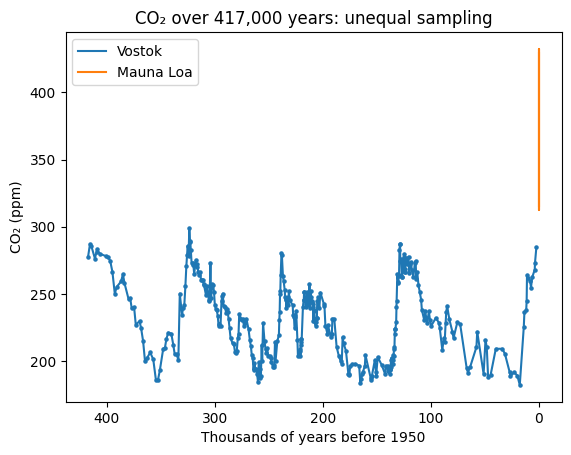

In [37]:
core = vostok.groupby("gas_age_bp").co2_ppm.mean()
plt.plot(core.index / 1000, core, label="Vostok")
plt.scatter(vostok.gas_age_bp / 1000, vostok.co2_ppm, s=5)
plt.plot((1950 - co2.decimal_date) / 1000, co2.average, label="Mauna Loa")
plt.gca().invert_xaxis()
plt.xlabel("Thousands of years before 1950")
plt.ylabel("CO₂ (ppm)")
plt.title("CO₂ over 417,000 years: unequal sampling")
plt.legend()
plt.show()

### What the comparison shows

The unusually high modern concentration is a finding in these CO₂ records. The nearly vertical modern line partly reflects the long time axis, so the plot needs careful interpretation.

**Answer:** July 2026 CO₂ is 429.12 ppm, about 130.42 ppm (43.66%) above the highest sampled Vostok value, 298.7 ppm. That's a real difference in the measured values, although ancient sampling could miss short spikes.

This doesn't directly test [Mann et al. (1998)](https://www.nature.com/articles/33859). Their paper reconstructs temperature over several centuries using multiple proxies. This plot compares CO₂ from Antarctic ice and modern air measurements over roughly 417,000 years. It fits the broader picture of rising greenhouse gases, but it can't establish the paper's temperature claim on its own.

Some of the shape comes from plotting choices. Around 68 years of modern measurements look almost vertical on a 400,000-year axis. Sparse ice-core samples and averaging also hide short-term changes. The separate Mauna Loa plot and the open gap help show these limits, so we wouldn't compare the slopes as if both records had the same resolution.


---

# Reflection

1. **Failure inventory.** List every case where the model produced code that ran without error but
   was wrong. What was wrong, and what tipped you off?
2. **Detection.** Which of those would you have caught from the plot alone? Which required going
   back to the source documentation?
3. **Division of labor.** What did you contribute that the model did not? If the answer for some
   task is "nothing", say so.
4. **Plan mode.** Where did approving the plan catch something? Where was it just friction?
5. **Tool choice.** You have now seen the same task done two ways, and data read locally versus
   streamed. What decides which is right, and who makes that decision?

**Reflection:**

1. **Failure inventory:** The main problems were wrong NOAA column labels, missing-value codes left in averages, Ibis reading the TXT as one column, `Z` being called total output, and adding stressors with different units. The sea-ice plot also had mismatched date axes; using Matplotlib for both lines fixed it. The old sea-ice filename, September-only coverage, and shorter Vostok file were caught before use. The 403 response was an access problem. An invalid progress-bar option also caused an error; setting it after connecting fixed it. The headline CO₂ sum included peat decay even though OWID excludes land-use change. Removing it fixed that boundary mismatch, but barely changed Estonia. The suggested claim that peat explained Estonia did not survive the regional check.
2. **Detection:** A large negative ice value or missing plot line could stand out visually. Wrong labels, the station change, gas age versus ice age, and emissions coverage needed the documentation. A plot looking reasonable was not enough.
3. **Division of labor:** We, Joseph Wong and Jacob Backus, split the work evenly. We used AI for the code and wrote the explanations ourselves. Each of us handled our share of the notebook sections. Our contribution was interpreting the results and explaining the checks, units, and limitations.
4. **Plan mode:** File coverage, units, and memory use were the important planning choices. The outdated filename and the difference between `Z` and total output show why those checks matter. This notebook does not record a separate approve-before-run step, so we cannot say that step caught the mistakes.
5. **Tool choice:** We would use pandas for the small tables and irregular text file, and Ibis/DuckDB for the large transaction table. The measured memory use supports that choice. Local versus remote access also affects timing, so those runs should be compared separately.